#**🍔 Food Delivery Time Prediction using Machine Learning**
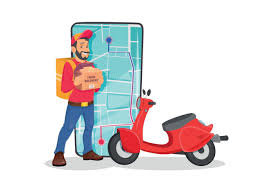

**Project Objective**

The objective of this project is to build a machine learning model that predicts food delivery time based on factors such as delivery partner details, traffic conditions, weather conditions, and distance between restaurant and delivery location.

This type of prediction helps companies like Swiggy, Zomato, and Uber Eats optimize delivery operations and improve customer satisfaction.

#**Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

#**Load Dataset**

In [2]:
df= pd.read_csv('/content/train.csv')
df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,conditions Windy,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 32
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,conditions Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 36
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,conditions Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,conditions Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 26


#**Dataset Overview**

Understanding dataset structure helps identify number of rows, columns, and data types.

In [3]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [4]:
df.tail()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,conditions Windy,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 32
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,conditions Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 36
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,conditions Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,conditions Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 26
45592,0x5fb2,RANCHIRES09DEL02,23,4.9,23.351058,85.325731,23.431058,85.405731,02-03-2022,17:10:00,17:15:00,conditions Fog,Medium,2,Snack,scooter,1,No,Metropolitian,(min) 36


In [5]:
df.shape

(45593, 20)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [7]:
#Check statistical values for fields with numerical datatype
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Restaurant_latitude,45593.0,17.017729,8.185109,-30.905562,12.933284,18.546947,22.728163,30.914057
Restaurant_longitude,45593.0,70.231332,22.883647,-88.366217,73.170000,75.898497,78.044095,88.433452
Delivery_location_latitude,45593.0,17.465186,7.335122,0.010000,12.988453,18.633934,22.785049,31.054057
Delivery_location_longitude,45593.0,70.845702,21.118812,0.010000,73.280000,76.002574,78.107044,88.563452
Vehicle_condition,45593.0,1.023359,0.839065,0.000000,0.000000,1.000000,2.000000,3.000000


In [8]:
#Check statistical values for fields with other than numerical datatype #df.describe(include='object').T
df.describe(exclude=np.number).T

,count,unique,top,freq
ID,45593,45593,0x5fb2,1
Delivery_person_ID,45593,1320,PUNERES01DEL01,67
Delivery_person_Age,45593,23,35,2262
Delivery_person_Ratings,45593,29,4.8,7148
Order_Date,45593,44,15-03-2022,1192
Time_Orderd,45593,177,NaN,1731
Time_Order_picked,45593,193,21:30:00,496
Weatherconditions,45593,7,conditions Fog,7654
Road_traffic_density,45593,5,Low,15477
Type_of_order,45593,4,Snack,11533


**Observation**

The dataset contains 45,593 rows and multiple features related to delivery operations.

#**Data Cleaning**

In [9]:
#Remove extra spaces in column names
df.columns = df.columns.str.strip()
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='object')

In [10]:
#Check Missing Values
df.isnull().sum().sum()

np.int64(0)

In [11]:
#Explore each column
for col in df.columns:
  print(col)
  print(df[col].value_counts())
  print('-------------------------')

ID
ID
0x5fb2     1
0x4607     1
0xb379     1
0x5d6d     1
0x7a6a     1
          ..
0xdb64     1
0xc8b6     1
0x2784     1
0xd987     1
0xcdcd     1
Name: count, Length: 45593, dtype: int64
-------------------------
Delivery_person_ID
Delivery_person_ID
PUNERES01DEL01       67
JAPRES11DEL02        67
VADRES08DEL02        66
RANCHIRES02DEL01     66
HYDRES04DEL02        66
                     ..
BHPRES15DEL03         7
GOARES01DEL03         7
KOLRES09DEL03         6
KOCRES16DEL03         6
BHPRES010DEL03        5
Name: count, Length: 1320, dtype: int64
-------------------------
Delivery_person_Age
Delivery_person_Age
35      2262
36      2260
37      2227
30      2226
38      2219
24      2210
32      2202
22      2196
29      2191
33      2187
28      2179
25      2174
34      2166
26      2159
21      2153
27      2150
39      2144
20      2136
31      2120
23      2087
NaN     1854
50        53
15        38
Name: count, dtype: int64
-------------------------
Delivery_person_Ratings
D

In [12]:
#Fix Time_taken(min) Column
# Remove (min) text and convert to numeric
df['Time_taken(min)'] = df['Time_taken(min)'].str.replace('(min)', '')
df['Time_taken(min)'] = df['Time_taken(min)'].astype(int)

#another_code: #df['Time_taken(min)'] = df['Time_taken(min)'].str.extract('(\d+)').astype(int)


In [13]:
df.head(3)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,26


In [14]:
#Convert Other Numeric Columns
df['Delivery_person_Age'] = pd.to_numeric(df['Delivery_person_Age'],errors='coerce')
df['Delivery_person_Ratings'] = pd.to_numeric(df['Delivery_person_Ratings'], errors='coerce')
df['multiple_deliveries'] = pd.to_numeric(df['multiple_deliveries'], errors='coerce')

In [15]:
#Handle Missing Values i.e Numeric Columns → Median
numeric_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries', 'Time_taken(min)']

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

#Explanation
#Median is used because it is robust to outliers.
#another_code:#df['Delivery_person_Age'].fillna(df['Delivery_person_Age'].median(), inplace=True)

/tmp/ipykernel_32683/486509765.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [16]:
#Categorical Columns → Mode
cat_cols= ['Festival','City','Road_traffic_density','Weatherconditions']

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_32683/1324686625.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [17]:
#changing col names
df.rename(columns={'Weatherconditions':'Weather_conditions','Time_Orderd':'Time_Ordered'}, inplace=True)

#another_method: df.rename(columns={'old_col_name':'new_col_name'}, inplace=True)

In [18]:
#updating the col
df['Weather_conditions'] = df['Weather_conditions'].str.replace('conditions ', '')

In [19]:
#Check Duplicate Rows
df.duplicated().sum()

np.int64(0)

#**Feature Engineering**

In [20]:
#Convert Time Columns
df['Time_Ordered'] = pd.to_datetime(df['Time_Ordered'], errors='coerce')
df['order_hour'] = df['Time_Ordered'].dt.hour

/tmp/ipykernel_32683/3575778241.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time_Ordered'] = pd.to_datetime(df['Time_Ordered'], errors='coerce')


In [21]:
#Calculate Delivery Distance - Distance between restaurant and delivery location is one of the most important features.
from geopy.distance import geodesic

def calculate_distance(row):

    restaurant = (row['Restaurant_latitude'], row['Restaurant_longitude'])
    delivery = (row['Delivery_location_latitude'], row['Delivery_location_longitude'])

    return geodesic(restaurant, delivery).km

df['Distance_km'] = df.apply(calculate_distance, axis=1)

In [22]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Ordered',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)',
       'order_hour', 'Distance_km'],
      dtype='object')

In [23]:
#Remove Unnecessary Columns
df.drop(['ID', 'Delivery_person_ID', 'Order_Date', 'Time_Ordered', 'Time_Order_picked'], axis= 1, inplace = True)

In [24]:
#df.columns

#**Exploratory Data Analysis (EDA)**

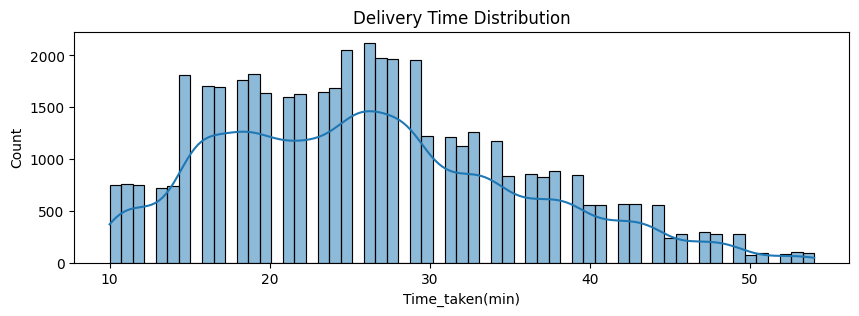

In [25]:
#Delivery Time Distribution
plt.figure(figsize=(10,3))
sns.histplot(df['Time_taken(min)'], kde=True)
plt.title('Delivery Time Distribution')
plt.show()

**Observation**


Most deliveries fall within a moderate time range.

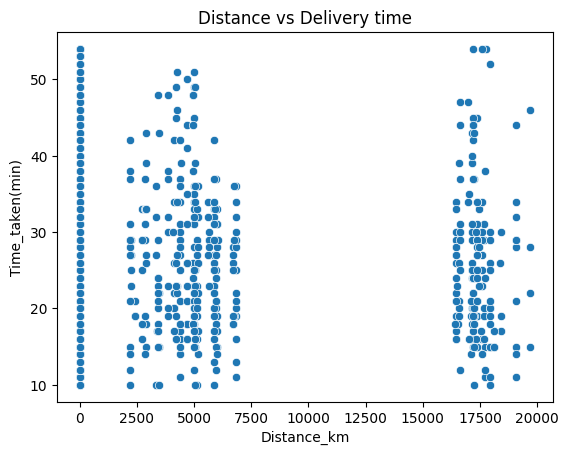

In [26]:
#Distance vs Delivery Time
sns.scatterplot(x=df['Distance_km'], y=df['Time_taken(min)'])
plt.title('Distance vs Delivery time')
plt.show()

**Observation**


Delivery time increases as delivery distance increases.

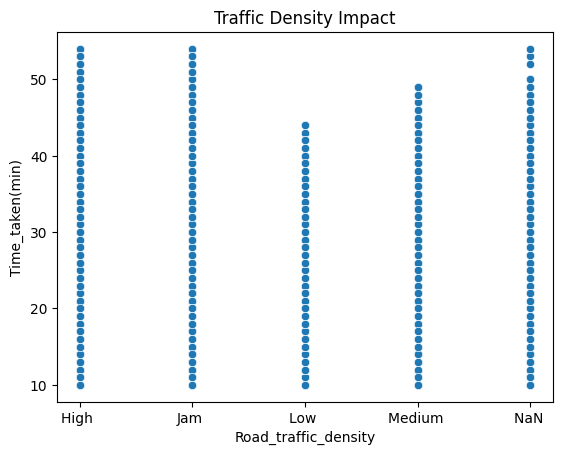

In [27]:
#Traffic Density Impact
sns.scatterplot(x = df['Road_traffic_density'], y= df['Time_taken(min)'])
plt.title('Traffic Density Impact')
plt.show()

**Observation**


Higher traffic density leads to longer delivery times.

#**LabelEncoding**

In [28]:
#Encode Categorical Features
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cat_cols = ['Weather_conditions','Road_traffic_density','Type_of_order','Type_of_vehicle','Festival','City']

for col in cat_cols:

    df[col] = le.fit_transform(df[col])

#another_code: df['cat_col_name'] = le.fit_transform(df['cat_col_name'])

**Data cleaning because of throws error in model training due to NAN values**

In [36]:
df.isnull().sum()

,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Weather_conditions,0
Road_traffic_density,0
Vehicle_condition,0
Type_of_order,0


In [38]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_32683/683477553.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [31]:
#cat_cols = df.select_dtypes(include='object').columns

#for col in cat_cols:
    #df[col].fillna(df[col].mode()[0], inplace=True)

In [40]:
df.isnull().sum()

,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Weather_conditions,0
Road_traffic_density,0
Vehicle_condition,0
Type_of_order,0


#**Feature Selection**

In [41]:
X = df.drop('Time_taken(min)', axis=1)  # Features
y = df['Time_taken(min)']  # Target variable

In [42]:
#Train-Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state = 42)

In [43]:
#Train Models
#Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [47]:
#Model Prediction using lr
y_pred_lr = lr.predict(X_test)
y_pred_lr

array([35.0437892 , 33.02165589, 32.33932314, ..., 23.60120908,
       26.65574978, 18.38511243])

In [44]:
#Random Forest Model
from sklearn.ensemble import RandomForestRegressor

rf= RandomForestRegressor()
rf.fit(X_train,y_train)

RandomForestRegressor()

In [48]:
#Model Prediction using rf
y_pred_rf = rf.predict(X_test)
y_pred_rf

array([41.77, 41.63, 35.77, ..., 20.85, 29.  , 28.78])

In [58]:
#Model Evaluation
#RMSE_lr

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("RMSE:", rmse)

RMSE: 6.972675329100357


In [59]:
#RMSE_rf

rsme_rf = np.sqrt(mean_squared_error(y_test,y_pred_rf))

print('RMSE:', rsme)


RMSE: 4.030511476928719


In [60]:
#MAE_lr

mae_lr = mean_absolute_error(y_test,y_pred_lr)

print('MAE:', mae_lr)

MAE: 5.5760533211031795


In [61]:
#MAE_rf

mae_rf = mean_absolute_error(y_test,y_pred_rf)
print('MAE:' , mae_rf)

MAE: 3.2002324816317578


In [62]:
#R² Score_lr

r2_lr = r2_score(y_test,y_pred_lr)

print("R2 Score:", r2_lr)

R2 Score: 0.4454923079007944


In [63]:
#R² Score_rf

r2_rf = r2_score(y_test,y_pred_rf)
print("R2 Score:", r2_rf)

R2 Score: 0.814719799350865


#**Feature Importance**


Feature importance shows which variables influence delivery time most.

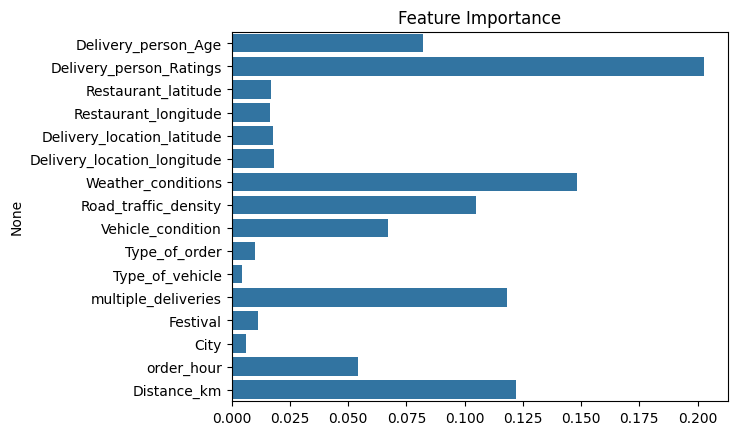

In [64]:
importance = rf.feature_importances_
features = X.columns
sns.barplot(x=importance, y= features)
plt.title("Feature Importance")
plt.show()

**Observation**

1. Weather conditions have the highest impact on delivery time, indicating that factors like rain, fog, or storms significantly slow down deliveries.

2. Delivery person ratings also influence delivery efficiency, as experienced or highly rated delivery partners may complete deliveries faster.

3. Distance between the restaurant and delivery location is another key factor affecting delivery time.

4. Multiple deliveries assigned to a delivery partner can increase delivery time due to additional stops.


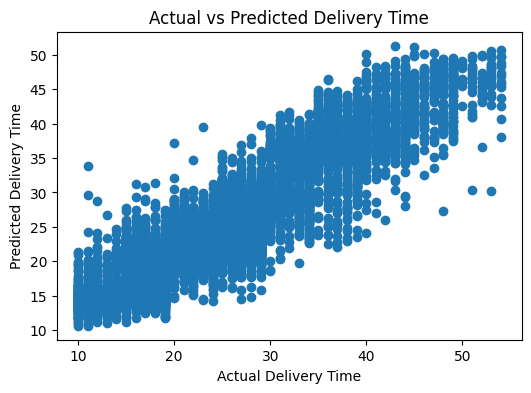

In [68]:
#Actual vs Predicted Plot for rf
plt.figure(figsize=(6,4))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Delivery Time")

plt.ylabel("Predicted Delivery Time")

plt.title("Actual vs Predicted Delivery Time")

plt.show()

# Conclusion

Key insights from the project:

• Delivery distance is the most influential factor affecting delivery time

• Traffic density significantly impacts delivery delays

• Random Forest performed better than Linear Regression for prediction

This model can help delivery platforms estimate delivery times more accurately.